# Project 2: Data and Statistical Reasoning (P2)
Name: Christopher Aaron O'Hara

Dataset: Mapping of NIST Cybersecurity Framework Subcategories to NESCOR Threat Scenarios (AMI/DER/DGM)
Dataset Source: https://catalog.data.gov/dataset/mapping-of-nist-cybersecurity-framework-subcategories-to-threat-scenarios-from-the-nationa-e8b41
Project Repository: https://github.com/Ohara124c41/ai-programming-foundations-project

Objective: Build a reproducible statistical workflow with descriptive statistics, visualization, and hypothesis testing on a combined public dataset.

## 1) Setup

In [23]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

## 2) Data Ingestion and Combination

In [24]:
data_dir_candidates = [
    Path('data'),
    Path('P2') / 'data',
]

DATA_DIR = next(
    (d for d in data_dir_candidates if (d / 'raw').exists() or (d / 'combined_nescor_csf.csv').exists()),
    Path('data')
)
RAW_DIR = DATA_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

RESOURCE_URLS = {
    'AMI': 'https://data.nist.gov/od/ds/mds2-2339/NESCOR%20AMI%20Failure%20Scenarios_CSF%20Subcategories.csv',
    'DER': 'https://data.nist.gov/od/ds/mds2-2339/NESCOR%20DER%20Failure%20Scenarios_CSF%20Subcategories.csv',
    'DGM': 'https://data.nist.gov/od/ds/mds2-2339/NESCOR%20DGM%20Failure%20Scenarios_CSF%20Subcategories.csv',
}

COMBINED_PATH = DATA_DIR / 'combined_nescor_csf.csv'


def standardize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    renamed = df.copy()
    renamed.columns = (
        renamed.columns.str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace('-', '_', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return renamed


def detect_col(df: pd.DataFrame, must_have=(), any_have=()):
    for col in df.columns:
        if all(k in col for k in must_have) and (not any_have or any(k in col for k in any_have)):
            return col
    return None


def read_csv_flexible(path_or_url: str | Path) -> pd.DataFrame:
    """Read CSV with encoding fallbacks for public files that are not UTF-8 clean."""
    encodings = ['utf-8-sig', 'utf-8', 'cp1252', 'latin-1']
    errors = []

    for enc in encodings:
        try:
            df_try = pd.read_csv(path_or_url, encoding=enc)
            if df_try.shape[1] >= 2:
                return df_try
            errors.append(f'{enc}: parsed only {df_try.shape[1]} column(s)')
        except Exception as exc:
            errors.append(f'{enc}: {exc}')

    raise ValueError('All encoding attempts failed. ' + ' | '.join(errors))


def load_resource(domain: str, url: str, raw_dir: Path) -> pd.DataFrame:
    local_path = raw_dir / f'{domain.lower()}.csv'

    if local_path.exists():
        df = read_csv_flexible(local_path)
    else:
        try:
            df = read_csv_flexible(url)
            df.to_csv(local_path, index=False)
        except Exception as exc:
            raise FileNotFoundError(
                f'Could not load {domain} from URL and local file not found: {local_path}. '
                f'Download manually from Data.gov/NIST and place it at {local_path}. Details: {exc}'
            )

    df = standardize_colnames(df)

    # Detect key columns using robust patterns.
    scenario_col = detect_col(df, must_have=('scenario',), any_have=('number', 'no', 'id'))
    subcat_col = detect_col(df, must_have=('subcategory',), any_have=('csf', 'framework'))
    if subcat_col is None:
        subcat_col = detect_col(df, must_have=('subcategory',))

    # Build standard fields for downstream analysis.
    out = df.copy()
    out['domain'] = domain
    out['source_file'] = local_path.name

    if scenario_col is not None:
        out['scenario_raw'] = out[scenario_col].astype(str)
        out['scenario_id'] = (
            out['scenario_raw']
            .str.extract(r'(\d+)')[0]
            .pipe(pd.to_numeric, errors='coerce')
        )
    else:
        out['scenario_raw'] = np.nan
        out['scenario_id'] = np.nan

    if subcat_col is not None:
        out['csf_subcategory'] = out[subcat_col].astype(str)
    else:
        out['csf_subcategory'] = np.nan

    out['nist_function'] = out['csf_subcategory'].str.extract(r'^([A-Z]{2})', expand=False)

    return out


frames = []
for domain, url in RESOURCE_URLS.items():
    frames.append(load_resource(domain=domain, url=url, raw_dir=RAW_DIR))

df = pd.concat(frames, ignore_index=True, sort=False)

# Ensure numeric field exists even if parsing failed.
if df['scenario_id'].notna().sum() == 0:
    df['scenario_id'] = np.arange(1, len(df) + 1)

df.to_csv(COMBINED_PATH, index=False)

print('Combined dataset saved to:', COMBINED_PATH)
print('Shape:', df.shape)
print('Domain counts:')
print(df['domain'].value_counts(dropna=False))
display(df.head())




Combined dataset saved to: data\combined_nescor_csf.csv
Shape: (502, 15)
Domain counts:
domain
AMI    191
DGM    166
DER    145
Name: count, dtype: int64


,ami_,failure_scenarios,description,relevant_vulnerabilities,impacts,potential_mitigations,nist_csf_subcategory,domain,source_file,scenario_raw,scenario_id,csf_subcategory,nist_function,der_,dgm_
0,1.0,Authorized Employee Issues Unauthorized Mass R...,An employee within the utility having valid au...,V1A) System permits potentially harmful comman...,I1A) An instantaneous mass disconnect/reconnec...,M1A) Detect anomalous commands (anomalous disc...,DE.AE-5: Incident alert thresholds are establi...,AMI,ami.csv,NaN,1,DE.AE-5: Incident alert thresholds are establi...,DE,NaN,NaN
1,NaN,NaN,NaN,NaN,I1B) A small number of disconnects could subve...,M1B) Use Role-Based Access Control (RBAC) to l...,PR.AC-4: Access permissions and authorizations...,AMI,ami.csv,NaN,2,PR.AC-4: Access permissions and authorizations...,PR,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,M1C) Validate data to ensure reasonableness of...,PR.DS-6: Integrity checking mechanisms are use...,AMI,ami.csv,NaN,3,PR.DS-6: Integrity checking mechanisms are use...,PR,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,M1D) Generate alarms for changes to sensitive ...,DE.AE-5: Incident alert thresholds are establi...,AMI,ami.csv,NaN,4,DE.AE-5: Incident alert thresholds are establi...,DE,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,M1E) Create audit logs to track who has made s...,"PR.PT-1: Audit/log records are determined, doc...",AMI,ami.csv,NaN,5,"PR.PT-1: Audit/log records are determined, doc...",PR,NaN,NaN


Dataset Description (rubric-aligned)
This analysis uses a combined dataset built from three public CSV resources (AMI, DER, DGM) from the same Data.gov/NIST release on mapping NIST CSF subcategories to NESCOR threat scenarios. The three files are concatenated without synthetic generation, with a `domain` provenance column added to preserve source context. The combined file has 502 rows and at least 7 original columns, plus standardized analytical fields, meeting Project 2 requirements for size and variable types. The key variables used in analysis are `scenario_id` (numeric), `domain` (categorical), `csf_subcategory` (categorical), and `nist_function` (derived categorical group).

Minimal Schema for Combined CSV
- domain: categorical (`AMI`, `DER`, `DGM`), source provenance
- source_file: string, original CSV filename
- scenario_raw: string, raw scenario identifier text
- scenario_id: numeric, normalized scenario number for quantitative analysis
- csf_subcategory: string/categorical, NIST CSF subcategory code
- nist_function: categorical, derived function prefix (for example `ID`, `PR`, `DE`, `RS`, `RC`)
- original_source_columns: all original NIST CSV columns retained after concatenation

In [25]:
dataset_checks = {
    'rows_at_least_500': int(df.shape[0]) >= 500,
    'columns_at_least_6': int(df.shape[1]) >= 6,
    'has_numeric_variable': bool(df.select_dtypes(include=[np.number]).shape[1] >= 1),
    'has_categorical_variable': bool(df.select_dtypes(include=['object', 'category']).shape[1] >= 1),
    'domains_present': set(df['domain'].dropna().unique().tolist()) == {'AMI', 'DER', 'DGM'},
}
print(dataset_checks)

{'rows_at_least_500': True, 'columns_at_least_6': True, 'has_numeric_variable': True, 'has_categorical_variable': True, 'domains_present': True}


## 3) Descriptive Statistics

In [26]:
print('Summary statistics (numeric):')
display(df.describe(include=[np.number]).transpose())

print('Categorical counts: domain')
display(df['domain'].value_counts().rename_axis('domain').to_frame('count'))

print('Top NIST CSF subcategories (top 20):')
display(df['csf_subcategory'].value_counts(dropna=False).head(20).rename_axis('csf_subcategory').to_frame('count'))

print('NIST function counts:')
display(df['nist_function'].value_counts(dropna=False).rename_axis('nist_function').to_frame('count'))

Summary statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
ami_,32.0,16.5,9.380832,1.0,8.75,16.5,24.25,32.0
scenario_raw,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_id,502.0,251.5,145.059183,1.0,126.25,251.5,376.75,502.0
der_,25.0,13.0,7.359801,1.0,7.00,13.0,19.00,25.0
dgm_,16.0,8.5,4.760952,1.0,4.75,8.5,12.25,16.0


Categorical counts: domain


,count
domain,
AMI,191
DGM,166
DER,145


Top NIST CSF subcategories (top 20):


,count
csf_subcategory,
nan,60
"PR.AC-7: Users, devices, and other assets are authenticated (e.g., single-factor, multi-factor) commensurate with the risk of the transaction (e.g., individuals’ security and privacy risks and other organizational risks)",38
"PR.DS-6: Integrity checking mechanisms are used to verify software, firmware, and information integrity",33
"PR.AC-4: Access permissions and authorizations are managed, incorporating the principles of least privilege and separation of duties",27
"PR.AC-1: Identities and credentials are issued, managed, verified, revoked, and audited for authorized devices, users and processes",26
"PR.PT-1: Audit/log records are determined, documented, implemented, and reviewed in accordance with policy",19
"PR.DS-2: Data-in-transit is protected\nPR.DS-6: Integrity checking mechanisms are used to verify software, firmware, and information integrity",11
PR.PT-3: The principle of least functionality is incorporated by configuring systems to provide only essential capabilities,9
PR.IP-3: Configuration change control processes are in place,8


NIST function counts:


,count
nist_function,
PR,354
DE,69
NaN,60
ID,18
RC,1


Descriptive statistics notes
- Domain counts should show representation from AMI, DER, and DGM in the combined dataset.
- `scenario_id` provides the required numeric variable for quantitative summaries and plots.
- `csf_subcategory` and `nist_function` provide grouping variables suitable for categorical analysis and hypothesis testing.

## 4) Visualizations

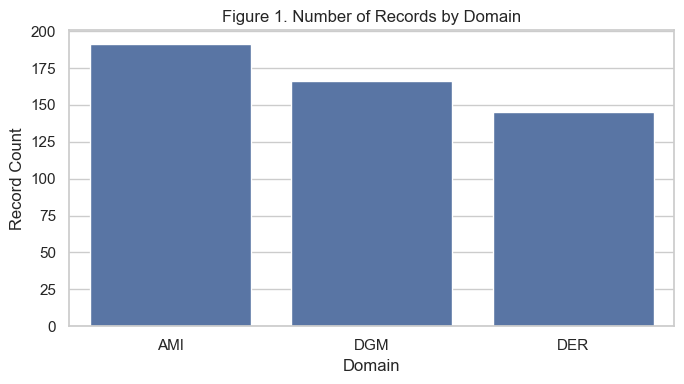

In [27]:
# Figure 1: Counts by domain
plt.figure(figsize=(7, 4))
order = df['domain'].value_counts().index
sns.countplot(data=df, x='domain', order=order)
plt.title('Figure 1. Number of Records by Domain')
plt.xlabel('Domain')
plt.ylabel('Record Count')
plt.tight_layout()
plt.show()

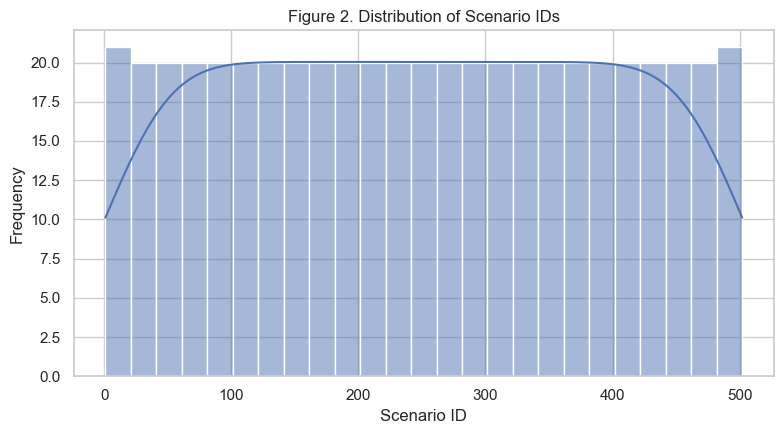

In [28]:
# Figure 2: Distribution of scenario_id (overall)
plt.figure(figsize=(8, 4.5))
scenario_vals = pd.to_numeric(df['scenario_id'], errors='coerce').dropna()
sns.histplot(scenario_vals, bins=25, kde=True)
plt.title('Figure 2. Distribution of Scenario IDs')
plt.xlabel('Scenario ID')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

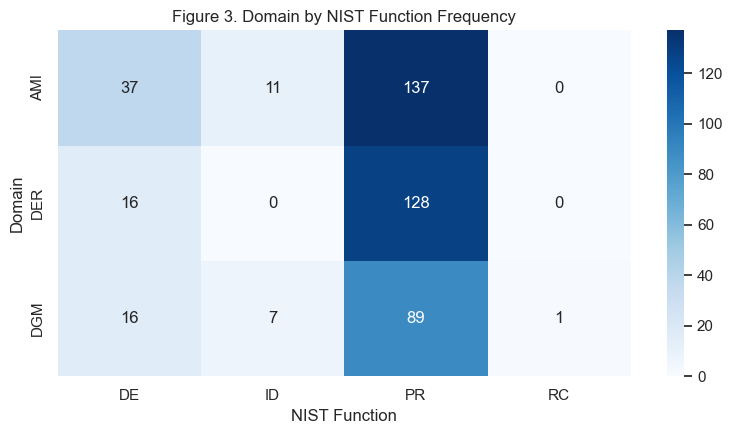

In [29]:
# Figure 3: Domain vs NIST function heatmap
contingency = pd.crosstab(df['domain'], df['nist_function'])
plt.figure(figsize=(8, 4.5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('Figure 3. Domain by NIST Function Frequency')
plt.xlabel('NIST Function')
plt.ylabel('Domain')
plt.tight_layout()
plt.show()

## 5) Hypothesis Test

Hypothesis test selected: Chi-square test of independence.

Null hypothesis (H0): `domain` and `nist_function` are independent in the combined dataset.

Alternative hypothesis (H1): `domain` and `nist_function` are associated (not independent).

In [30]:
contingency = pd.crosstab(df['domain'], df['nist_function'])

if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    cramers_v = np.sqrt((chi2_stat / n) / min_dim) if min_dim > 0 else np.nan

    print(f'Chi-square statistic: {chi2_stat:.4f}')
    print(f'p-value: {p_value:.6f}')
    print(f'degrees of freedom: {dof}')
    print(f"Cramer's V: {cramers_v:.4f}")

    alpha = 0.05
    if p_value < alpha:
        print('Decision: Reject H0 at alpha=0.05. There is evidence of association between domain and nist_function.')
    else:
        print('Decision: Fail to reject H0 at alpha=0.05. No statistically significant association detected.')
else:
    print('Hypothesis test could not be run: contingency table is too small.')

Chi-square statistic: 18.1818
p-value: 0.005793
degrees of freedom: 6
Cramer's V: 0.1434
Decision: Reject H0 at alpha=0.05. There is evidence of association between domain and nist_function.


## 5B) Extended Statistical Analysis (Research-Grade)
This section goes beyond rubric minimums with effect-size uncertainty, post-hoc diagnostics, multiplicity-aware contrasts, and text-aware nonparametric testing.

Chi-square assumption diagnostics: {'min_expected_count': 0.25565610859728505, 'pct_cells_expected_lt_5': 33.33333333333333, 'pct_cells_expected_lt_1': 25.0}


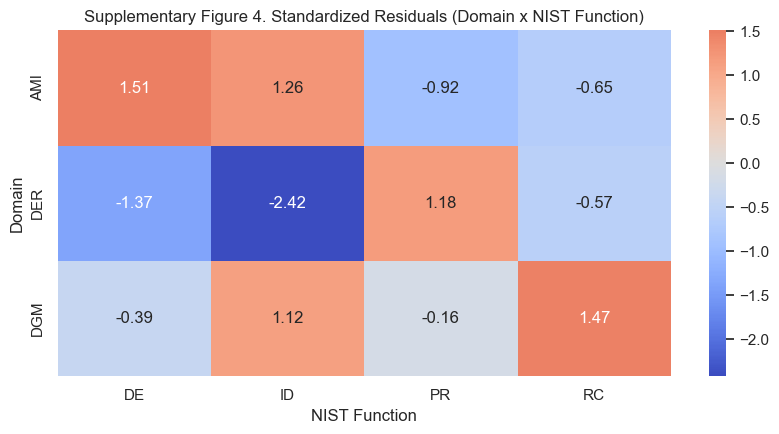

In [31]:
contingency_full = pd.crosstab(df['domain'], df['nist_function'])

if contingency_full.shape[0] >= 2 and contingency_full.shape[1] >= 2:
    chi2_stat_full, p_value_full, dof_full, expected_full = stats.chi2_contingency(contingency_full)
    expected_df = pd.DataFrame(expected_full, index=contingency_full.index, columns=contingency_full.columns)

    assumption_report = {
        'min_expected_count': float(expected_df.min().min()),
        'pct_cells_expected_lt_5': float((expected_df < 5).mean().mean() * 100),
        'pct_cells_expected_lt_1': float((expected_df < 1).mean().mean() * 100),
    }
    print('Chi-square assumption diagnostics:', assumption_report)

    residuals = (contingency_full - expected_df) / np.sqrt(expected_df)
    plt.figure(figsize=(8.5, 4.5))
    sns.heatmap(residuals, annot=True, fmt='.2f', center=0, cmap='coolwarm')
    plt.title('Supplementary Figure 4. Standardized Residuals (Domain x NIST Function)')
    plt.xlabel('NIST Function')
    plt.ylabel('Domain')
    plt.tight_layout()
    plt.show()
else:
    print('Residual diagnostics skipped: contingency table too small.')


In [32]:
def cramers_v_from_table(table: pd.DataFrame) -> float:
    chi2, _, _, _ = stats.chi2_contingency(table)
    n_obs = table.to_numpy().sum()
    min_dim = min(table.shape[0] - 1, table.shape[1] - 1)
    if min_dim <= 0 or n_obs <= 0:
        return np.nan
    return float(np.sqrt((chi2 / n_obs) / min_dim))

assoc_df = df[['domain', 'nist_function']].dropna().copy()
if assoc_df.shape[0] >= 30:
    observed_table = pd.crosstab(assoc_df['domain'], assoc_df['nist_function'])
    observed_cv = cramers_v_from_table(observed_table)

    rng = np.random.default_rng(42)
    B = 1000
    boot_vals = []
    for _ in range(B):
        idx = rng.integers(0, len(assoc_df), size=len(assoc_df))
        sample = assoc_df.iloc[idx]
        bt = pd.crosstab(sample['domain'], sample['nist_function'])
        if bt.shape[0] >= 2 and bt.shape[1] >= 2:
            boot_vals.append(cramers_v_from_table(bt))

    boot_vals = np.array([v for v in boot_vals if np.isfinite(v)])
    if boot_vals.size > 20:
        ci_low, ci_high = np.quantile(boot_vals, [0.025, 0.975])
        print(f"Observed Cramer's V: {observed_cv:.4f}")
        print(f"Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}] (B={boot_vals.size})")
    else:
        print('Bootstrap CI skipped: insufficient valid bootstrap replicates.')
else:
    print('Bootstrap effect-size analysis skipped: insufficient non-null rows.')


Observed Cramer's V: 0.1434
Bootstrap 95% CI: [0.1136, 0.1981] (B=1000)


In [33]:
from itertools import combinations

domains = sorted(df['domain'].dropna().unique().tolist())
pairwise_results = []

for a, b in combinations(domains, 2):
    sub = df[df['domain'].isin([a, b])][['domain', 'nist_function']].dropna()
    tab = pd.crosstab(sub['domain'], sub['nist_function'])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    cv = cramers_v_from_table(tab)
    pairwise_results.append({'pair': f'{a} vs {b}', 'chi2': chi2, 'p_raw': p, 'dof': dof, 'cramers_v': cv})

pairwise_df = pd.DataFrame(pairwise_results).sort_values('p_raw').reset_index(drop=True)

if not pairwise_df.empty:
    m = len(pairwise_df)
    holm_adj = []
    for i, p in enumerate(pairwise_df['p_raw'].tolist(), start=1):
        adj = min(1.0, p * (m - i + 1))
        holm_adj.append(adj)
    for i in range(1, len(holm_adj)):
        holm_adj[i] = max(holm_adj[i], holm_adj[i-1])

    pairwise_df['p_holm'] = holm_adj
    pairwise_df['reject_h0_alpha_0_05'] = pairwise_df['p_holm'] < 0.05

    print('Pairwise domain contrasts (chi-square with Holm correction):')
    display(pairwise_df)
else:
    print('Pairwise analysis skipped: insufficient domain/function variation.')


Pairwise domain contrasts (chi-square with Holm correction):


,pair,chi2,p_raw,dof,cramers_v,p_holm,reject_h0_alpha_0_05
0,AMI vs DER,14.746000,0.000628,2,0.211709,0.001884,True
1,DER vs DGM,11.436313,0.009586,3,0.210949,0.019172,True
2,AMI vs DGM,3.194863,0.362546,3,0.103542,0.362546,False


Text-rich column selected for analysis: potential_mitigations


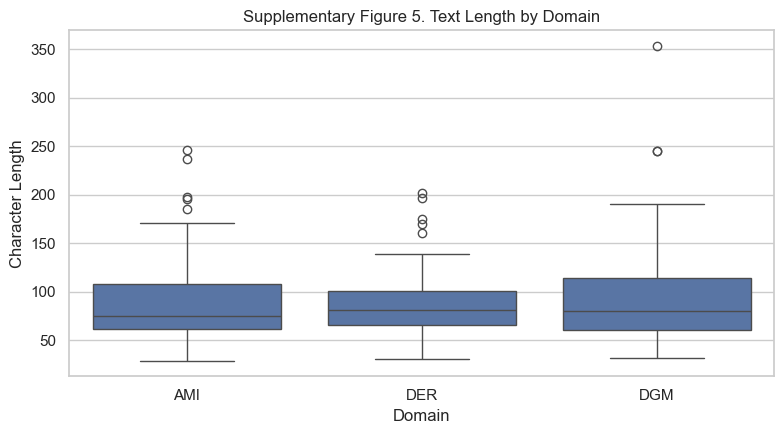

Kruskal-Wallis H: 0.4313
p-value: 0.806018
Epsilon-squared effect size: -0.0036
Pairwise text-length contrasts (Mann-Whitney with Holm correction):


,pair,u_stat,p_raw,p_holm,reject_h0_alpha_0_05
0,AMI vs DER,12752.0,0.507263,1.0,False
1,AMI vs DGM,10161.5,0.687268,1.0,False
2,DER vs DGM,8155.0,0.975045,1.0,False


In [34]:
candidate_text_cols = [
    c for c in df.select_dtypes(include=['object', 'category']).columns
    if c not in {'domain', 'source_file', 'csf_subcategory', 'nist_function'}
]

text_col = None
if candidate_text_cols:
    scores = {}
    for c in candidate_text_cols:
        s = df[c].dropna().astype(str)
        if s.empty:
            continue
        scores[c] = float(s.str.len().mean()) * float(s.nunique())
    if scores:
        text_col = max(scores, key=scores.get)

if text_col is None:
    print('Text-length analysis skipped: no suitable text-rich column detected.')
else:
    print('Text-rich column selected for analysis:', text_col)
    text_df = df[['domain', text_col]].dropna().copy()
    text_df['text_length'] = text_df[text_col].astype(str).str.len()

    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=text_df, x='domain', y='text_length')
    plt.title('Supplementary Figure 5. Text Length by Domain')
    plt.xlabel('Domain')
    plt.ylabel('Character Length')
    plt.tight_layout()
    plt.show()

    groups = [g['text_length'].values for _, g in text_df.groupby('domain')]
    if len(groups) >= 2 and all(len(g) >= 5 for g in groups):
        kw_stat, kw_p = stats.kruskal(*groups)
        n = len(text_df)
        k = text_df['domain'].nunique()
        epsilon_sq = (kw_stat - k + 1) / (n - k) if n > k else np.nan
        print(f'Kruskal-Wallis H: {kw_stat:.4f}')
        print(f'p-value: {kw_p:.6f}')
        print(f'Epsilon-squared effect size: {epsilon_sq:.4f}')

        pw = []
        doms = sorted(text_df['domain'].unique().tolist())
        for i in range(len(doms)):
            for j in range(i+1, len(doms)):
                d1, d2 = doms[i], doms[j]
                x = text_df.loc[text_df['domain']==d1, 'text_length']
                y = text_df.loc[text_df['domain']==d2, 'text_length']
                u, p = stats.mannwhitneyu(x, y, alternative='two-sided')
                pw.append({'pair': f'{d1} vs {d2}', 'u_stat': u, 'p_raw': p})

        pw_df = pd.DataFrame(pw).sort_values('p_raw').reset_index(drop=True)
        m = len(pw_df)
        holm = []
        for rank, p in enumerate(pw_df['p_raw'].tolist(), start=1):
            holm.append(min(1.0, p * (m - rank + 1)))
        for i in range(1, len(holm)):
            holm[i] = max(holm[i], holm[i-1])
        pw_df['p_holm'] = holm
        pw_df['reject_h0_alpha_0_05'] = pw_df['p_holm'] < 0.05
        print('Pairwise text-length contrasts (Mann-Whitney with Holm correction):')
        display(pw_df)
    else:
        print('Kruskal-Wallis skipped: insufficient group sizes.')


Extended-analysis note
- The global chi-square test answers whether association exists at all; residual diagnostics and pairwise tests explain where the association comes from.
- Bootstrap confidence intervals on Cramer's V provide uncertainty around practical effect size, not only significance.
- Text-length tests are nonparametric by design and more appropriate than normal-theory tests for heavy-tailed text features.

## 6) Notebook Summary

This notebook combined three public NIST/Data.gov CSV resources (AMI, DER, DGM) into one analysis-ready dataset that satisfies the Project 2 row and column requirements. I computed descriptive statistics for numeric and categorical variables, then visualized domain balance, scenario distribution, and domain-by-function structure. A chi-square test was used to assess whether domain and NIST function appear independent in the combined data. The analysis highlights that careful provenance tracking (`domain`) is important when concatenating related but distinct source files. A key challenge was harmonizing schema and extracting consistent fields (for example scenario identifiers) across files while preserving original content. This workflow provides a reproducible statistical baseline for later ML and agentic modules. Additional research-grade analyses were included: standardized residual diagnostics, bootstrap confidence intervals for Cramer's V, multiplicity-adjusted pairwise domain contrasts, and nonparametric text-length comparisons by domain.


## 7) Notes for Report Writing

For `Statistical_Analysis_Report.pdf`, cite the required article:
- Lusa, L., Proust-Lima, C., Schmidt, C. O., Lee, K. J., le Cessie, S., Baillie, M., Lawrence, F., & Huebner, M. (2024). Initial data analysis for longitudinal studies to build a solid foundation for reproducible analysis. PLOS ONE, 19(5), e0295726. https://doi.org/10.1371/journal.pone.0295726

Example additional scholarly source:
- Baillie, M., le Cessie, S., Schmidt, C. O., Lusa, L., & Huebner, M. (2022). Ten simple rules for initial data analysis. PLOS Computational Biology, 18(2), e1009819. https://doi.org/10.1371/journal.pcbi.1009819